Import CSV files in Google Colab

In [45]:
from google.colab import files

uploaded = files.upload()

Saving Salary_Data.csv to Salary_Data (1).csv


Import required libraries

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

Read CSV File

In [47]:
df = pd.read_csv('Salary_Data.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB
None
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director          

Checking Missing Values

In [48]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


Filling Missing Values by Mean

In [49]:
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

Checking Again Missing values

In [50]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,0
Salary,0


 Data Visualization

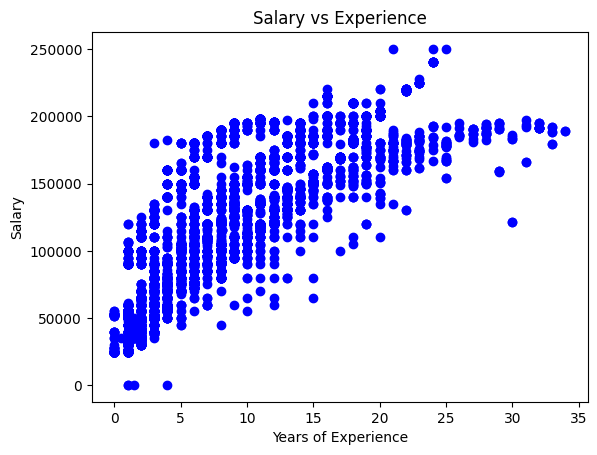

In [51]:
# x axis for years of Experience ans y - axis for salary
plt.scatter(df['Years of Experience'] , df['Salary'] , color ='blue')
plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

8.09468736009551
115326.9647708613


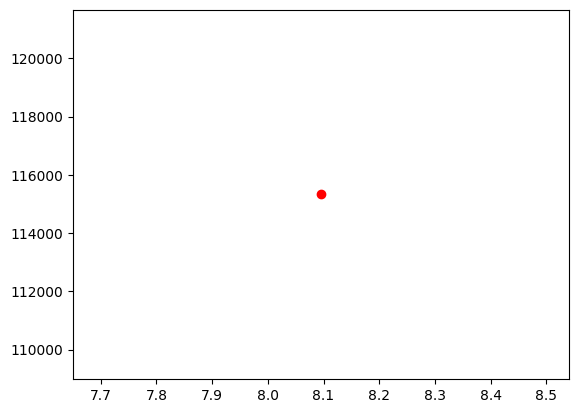

In [52]:
# Mean value
plt.scatter(df['Years of Experience'].mean() , df['Salary'].mean() , color ='red')
print(df['Years of Experience'].mean())
print(df['Salary'].mean())

Linear Regression

In [53]:
reg = LinearRegression()
reg.fit(df[['Years of Experience']] , df['Salary']) #train the Model

LinearRegression()

Slope & Intercept

In [54]:
print(reg.coef_)
print(reg.intercept_)

[7046.64236204]
58286.59791175786


Predict For a value

In [55]:
print(reg.predict([[1.1]]))

[66037.90451]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [56]:
df["Predicted Salary"] = reg.predict(df[["Years of Experience"]])
print(df)

       Age  Gender    Education Level              Job Title  \
0     32.0    Male         Bachelor's      Software Engineer   
1     28.0  Female           Master's           Data Analyst   
2     45.0    Male                PhD         Senior Manager   
3     36.0  Female         Bachelor's        Sales Associate   
4     52.0    Male           Master's               Director   
...    ...     ...                ...                    ...   
6699  49.0  Female                PhD  Director of Marketing   
6700  32.0    Male        High School        Sales Associate   
6701  30.0  Female  Bachelor's Degree      Financial Manager   
6702  46.0    Male    Master's Degree      Marketing Manager   
6703  26.0  Female        High School        Sales Executive   

      Years of Experience    Salary  Predicted Salary  
0                     5.0   90000.0      93519.809722  
1                     3.0   65000.0      79426.524998  
2                    15.0  150000.0     163986.233342  
3      

Best fit Line

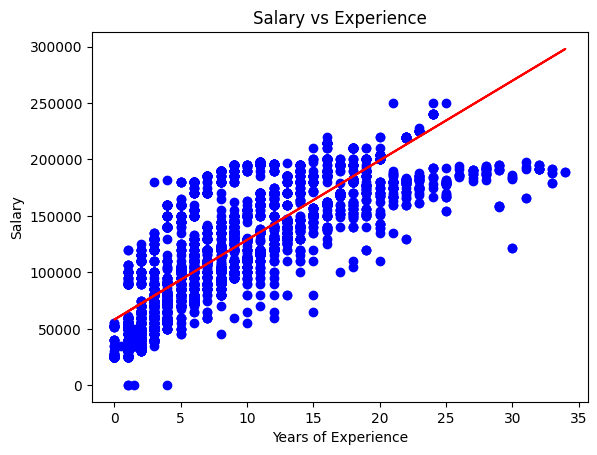

In [59]:
plt.scatter(df['Years of Experience'] , df['Salary'] , color ='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.plot(df['Years of Experience'] , reg.predict(df[['Years of Experience']]) , color ='red')
plt.show()

Lose & Cost Function

In [60]:
df['lose'] = df['Salary'] - df['Predicted Salary'] # Lose can be negative as well as positive
print(df.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  Predicted Salary          lose  
0   90000.0      93519.809722  -3519.809722  
1   65000.0      79426.524998 -14426.524998  
2  150000.0     163986.233342 -13986.233342  
3   60000.0     107613.094446 -47613.094446  
4  200000.0     199219.445153    780.554847  


Mean Squared Error & Mean Absolute Error

In [61]:
from sklearn.metrics import mean_squared_error , mean_absolute_error
mse = mean_squared_error(df['Salary'] , df['Predicted Salary'])
print(mse)

962058475.9348899


In [62]:
mae = mean_absolute_error(df['Salary'] , df['Predicted Salary'])
print(mae)

24870.22920775232


In [63]:
R = reg.score(df[['Years of Experience']] , df['Salary'])
print(R)


0.6544190457511312
